<a href="https://colab.research.google.com/github/nikensaras/Data-Analyst-Project/blob/main/AirBnB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [26]:
pip install sqlalchemy psycopg2-binary

In [27]:
!pip install kagglehub[pandas-datasets]

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sqlalchemy import create_engine
from urllib.parse import quote_plus
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Connect to SQL

In [ ]:
username = ""
password = quote_plus("")
host = ""
port = ""
database = "postgres"

DATABASE_URL = (
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

engine = create_engine(DATABASE_URL)

## Load dataset

In [29]:
file_path = "calendar.csv"

calendar = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "erikbruin/airbnb-amsterdam",
  file_path,
  pandas_kwargs={"nrows":100000}

)

/tmp/ipykernel_3571/1156873435.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  calendar = kagglehub.load_dataset(


100%|██████████| 17.0M/17.0M [00:00<00:00, 44.0MB/s]

Extracting zip of calendar.csv...


In [ ]:
calendar.to_sql('calendar', con=engine, schema='public', if_exists='replace', index=False)

1000

In [30]:
file_path = "listings.csv"

listings = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "erikbruin/airbnb-amsterdam",
  file_path,

)

/tmp/ipykernel_3571/825826744.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  listings = kagglehub.load_dataset(


100%|██████████| 1.11M/1.11M [00:00<00:00, 76.5MB/s]

Extracting zip of listings.csv...


In [ ]:
listings.to_sql('listings', con=engine, schema='public', if_exists='replace', index=False)

NameError: name 'listings' is not defined

# Read DataFrame

In [ ]:
calendar

,listing_id,date,available,price
0,2818,2019-12-05,f,NaN
1,73208,2019-08-30,f,NaN
2,73208,2019-08-29,f,NaN
3,73208,2019-08-28,f,NaN
4,73208,2019-08-27,f,NaN
...,...,...,...,...
99995,639480,2019-11-14,f,NaN
99996,639480,2019-11-13,f,NaN
99997,639480,2019-11-12,f,NaN
99998,639480,2019-11-11,f,NaN


In [ ]:
listings

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2818,Quiet Garden View Room & Super Fast WiFi,3159,Daniel,NaN,Oostelijk Havengebied - Indische Buurt,52.365755,4.941419,Private room,59,3,248,2018-11-28,2.10,1,44
1,3209,"Quiet apt near center, great view",3806,Maartje,NaN,Westerpark,52.390225,4.873924,Entire home/apt,160,4,42,2018-08-29,1.03,1,47
2,20168,100%Centre-Studio 1 Private Floor/Bathroom,59484,Alex,NaN,Centrum-Oost,52.365087,4.893541,Entire home/apt,80,1,233,2018-11-30,2.18,2,198
3,25428,Lovely apt in City Centre (Jordaan),56142,Joan,NaN,Centrum-West,52.373114,4.883668,Entire home/apt,125,14,1,2018-01-21,0.09,2,141
4,27886,"Romantic, stylish B&B houseboat in canal district",97647,Flip,NaN,Centrum-West,52.386727,4.892078,Private room,150,2,171,2018-11-25,2.03,1,199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20025,30576148,Family House City + free Parking+garden (160 m2),13399651,Marieke,NaN,Watergraafsmeer,52.345999,4.952145,Entire home/apt,340,7,0,NaN,NaN,1,11
20026,30577727,Home Sweet Home in Indische Buurt,1595885,Evita,NaN,Oostelijk Havengebied - Indische Buurt,52.362412,4.932467,Entire home/apt,150,3,0,NaN,NaN,2,16
20027,30578037,Amsterdam Cozy apartment nearby center,87866499,Tommaso,NaN,Oud-Oost,52.362431,4.926912,Entire home/apt,80,10,0,NaN,NaN,2,210
20028,30579673,Home Sweet Home for a Guest or a Couple,1595885,Evita,NaN,Oostelijk Havengebied - Indische Buurt,52.363780,4.932493,Private room,55,2,0,NaN,NaN,2,31


# Info Data

In [ ]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   listing_id  100000 non-null  int64 
 1   date        100000 non-null  object
 2   available   100000 non-null  object
 3   price       30893 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.1+ MB


In [ ]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20030 entries, 0 to 20029
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20030 non-null  int64  
 1   name                            19992 non-null  object 
 2   host_id                         20030 non-null  int64  
 3   host_name                       20026 non-null  object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   20030 non-null  object 
 6   latitude                        20030 non-null  float64
 7   longitude                       20030 non-null  float64
 8   room_type                       20030 non-null  object 
 9   price                           20030 non-null  int64  
 10  minimum_nights                  20030 non-null  int64  
 11  number_of_reviews               20030 non-null  int64  
 12  last_review                     

# Cleaning Data

## Data Duplikat

In [ ]:
calendar.duplicated().sum()

np.int64(0)

In [ ]:
listings.duplicated().sum()

np.int64(0)

## Data Missing Value

In [ ]:
calendar.isnull().sum()

,0
listing_id,0
date,0
available,0
price,69107


In [ ]:
listings.isnull().sum()

,0
id,0
name,38
host_id,0
host_name,4
neighbourhood_group,20030
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


# Isi Missing Values

In [ ]:
listings ['name'].fillna('unknown')

,name
0,Quiet Garden View Room & Super Fast WiFi
1,"Quiet apt near center, great view"
2,100%Centre-Studio 1 Private Floor/Bathroom
3,Lovely apt in City Centre (Jordaan)
4,"Romantic, stylish B&B houseboat in canal district"
...,...
20025,Family House City + free Parking+garden (160 m2)
20026,Home Sweet Home in Indische Buurt
20027,Amsterdam Cozy apartment nearby center
20028,Home Sweet Home for a Guest or a Couple


In [ ]:
listings ['host_name'].fillna('unknown')

,host_name
0,Daniel
1,Maartje
2,Alex
3,Joan
4,Flip
...,...
20025,Marieke
20026,Evita
20027,Tommaso
20028,Evita


In [ ]:
listings ['reviews_per_month'].fillna(0)

,reviews_per_month
0,2.10
1,1.03
2,2.18
3,0.09
4,2.03
...,...
20025,0.00
20026,0.00
20027,0.00
20028,0.00


# Ubah Tipe Data

In [ ]:
calendar['date'] = pd.to_datetime(calendar['date'])

In [ ]:
calendar['available'] = calendar['available'].map({'f':False, 't':True})

In [ ]:
calendar['price'] = calendar['price'].str.replace('$','').str.replace(',' '').astype(float)

TypeError: StringMethods.replace() missing 1 required positional argument: 'repl'

# Drop Kolom

In [ ]:
listings.drop(columns='neighbourhood_group',inplace=True)

In [ ]:
listings.drop(columns='last_review',inplace=True)

# Insight

## 1. Top neighbourhood paling banyak listing; harga paling mahal; review paling tinggi

In [ ]:
insight1 = pd.read_csv("https://raw.githubusercontent.com/nikensaras/Data-Analyst-Project/refs/heads/main/AirBnb/insight2.csv")

In [ ]:
insight1

,area,total_listing,avg_harga,avg_review
0,Centrum-West,2326,189.92,33.09
1,Centrum-Oost,1730,189.38,28.66
2,Zuid,1441,171.13,17.59
3,IJburg - Zeeburgereiland,452,165.16,17.85
4,Oud-Noord,571,157.68,21.68
5,De Pijp - Rivierenbuurt,2493,157.18,19.27
6,Buitenveldert - Zuidas,262,153.09,12.02
7,De Baarsjes - Oud-West,3515,143.85,19.35
8,Oud-Oost,1282,143.40,16.90
9,Westerpark,1490,141.00,19.11


In [ ]:
listings['neighbourhood'].value_counts().head(10)

,count
neighbourhood,
De Baarsjes - Oud-West,3515
De Pijp - Rivierenbuurt,2493
Centrum-West,2326
Centrum-Oost,1730
Westerpark,1490
Zuid,1441
Oud-Oost,1282
Bos en Lommer,1145
Oostelijk Havengebied - Indische Buurt,959


In [ ]:
listings.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)

,price
neighbourhood,
Centrum-West,189.920034
Centrum-Oost,189.376301
Zuid,171.126995
IJburg - Zeeburgereiland,165.157080
Oud-Noord,157.684764
De Pijp - Rivierenbuurt,157.178500
Buitenveldert - Zuidas,153.087786
De Baarsjes - Oud-West,143.849218
Oud-Oost,143.398596


In [ ]:
listings.groupby('neighbourhood')['number_of_reviews'].mean().sort_values(ascending=False).head(10)

,number_of_reviews
neighbourhood,
Centrum-West,33.089424
De Aker - Nieuw Sloten,30.640845
Centrum-Oost,28.664740
Bijlmer-Centrum,25.522523
Osdorp,24.371069
Bijlmer-Oost,23.468750
Noord-West,23.312500
Gaasperdam - Driemond,23.073770
Noord-Oost,22.700389


## 2. Rata-rata jumlah listing per tipe kamar

In [ ]:
listings['room_type'].value_counts().head(10)

,count
room_type,
Entire home/apt,15889
Private room,4076
Shared room,65


## 3. Rata-rata harga per tipe kamar

In [ ]:
insight3 = pd.read_csv("https://raw.githubusercontent.com/nikensaras/Data-Analyst-Project/refs/heads/main/AirBnb/insight1.csv")

In [ ]:
insight3

,tipe_kamar,jumlah_listing,rata_rata_harga,harga_minimum,harga_maximum
0,Entire home/apt,15889,165.78,0,8500
1,Private room,4076,100.13,19,5000
2,Shared room,65,92.00,25,302


In [ ]:
listings.groupby('room_type')['price'].mean().sort_values(ascending=False).head(10)

,price
room_type,
Entire home/apt,165.779659
Private room,100.131501
Shared room,92.000000


## 4. Host dengan kepemilikan properti termahal; Host dengan kepemilikan properti terbanyak

In [ ]:
insight4 = pd.read_csv("https://raw.githubusercontent.com/nikensaras/Data-Analyst-Project/refs/heads/main/AirBnb/insight3.csv")

In [ ]:
insight4

,host_name,jumlah_properti,rata_harga
0,Anubisdelvalle,1,5040.0
1,Faralda,4,1712.5
2,Khan,1,1500.0
3,JanDirk,1,1200.0
4,Mical,1,1050.0
5,Hedy,1,999.0
6,NicoPeg,1,900.0
7,Nilay,1,900.0
8,Casper & Simone,1,896.0
9,Wichard,1,875.0


In [ ]:
listings['host_name'].value_counts().head(10)

,count
host_name,
Martijn,289
Michiel And Jane,105
Laura,98
Anne,90
Eva,88
Marieke,88
Willem,87
Rated,83
Thomas,80


In [ ]:
listings.groupby('host_name')['price'].mean().sort_values(ascending=False).head(10)

,price
host_name,
Anubisdelvalle,5040.0
Faralda,1712.5
Khan,1500.0
JanDirk,1200.0
Mical,1050.0
Hedy,999.0
NicoPeg,900.0
Nilay,900.0
Casper & Simone,896.0


## 5. Tingkat ketersediaan listings per bulan

In [31]:
insight5 = pd.read_csv("https://raw.githubusercontent.com/nikensaras/Data-Analyst-Project/refs/heads/main/AirBnb/bookandnot.csv")

In [32]:
insight5

,bulan,bookingconfirmed,notbooked
0,1,5656,2827
1,2,4912,2760
2,3,5726,2768
3,4,6125,2095
4,5,6007,2487
5,6,5965,2255
6,7,6036,2458
7,8,5911,2583
8,9,5587,2633
9,10,5573,2921


In [ ]:
calendar['month'] = pd.to_datetime(calendar['date']).dt.month

calendar.groupby('month')['available'].value_counts().unstack().rename(
    columns={
        False: 'booked',
        True: 'available'
    }
)

available,booked,available
month,,
1,5656,2827
2,4912,2760
3,5726,2768
4,6125,2095
5,6007,2487
6,5965,2255
7,6036,2458
8,5911,2583
9,5587,2633


## 6. Neighbourhood berdasar Minimal Hari Menginap

In [ ]:
listings[['neighbourhood', 'room_type', 'minimum_nights', 'price']].sort_values('minimum_nights', ascending=False).head(5)

,neighbourhood,room_type,minimum_nights,price
12245,De Pijp - Rivierenbuurt,Private room,1001,130
2183,De Baarsjes - Oud-West,Entire home/apt,999,120
2932,Zuid,Private room,365,150
3668,Oostelijk Havengebied - Indische Buurt,Entire home/apt,365,100
18721,De Baarsjes - Oud-West,Entire home/apt,365,3000


In [ ]:
listings[['neighbourhood', 'room_type', 'minimum_nights', 'price']].sort_values('price', ascending=False).head(10)

,neighbourhood,room_type,minimum_nights,price
7234,Oud-Oost,Entire home/apt,3,8500
127,De Pijp - Rivierenbuurt,Entire home/apt,30,8000
19486,Centrum-West,Entire home/apt,3,5040
13009,IJburg - Zeeburgereiland,Private room,3,5000
3321,Oud-Noord,Entire home/apt,1,4500
16959,Zuid,Entire home/apt,30,3900
10008,Centrum-Oost,Entire home/apt,1,3142
18721,De Baarsjes - Oud-West,Entire home/apt,365,3000
12891,Centrum-Oost,Entire home/apt,10,2500
6591,Buitenveldert - Zuidas,Entire home/apt,30,2500


## 7. Kategori Kepemilikan Properti

In [ ]:
insight7 = pd.read_csv("https://raw.githubusercontent.com/nikensaras/Data-Analyst-Project/refs/heads/main/AirBnb/independentkomersil.csv")

In [ ]:
insight7

,nama_host,kepemilikan_properti,kategori
0,Martijn,208,Komersil
1,Michiel And Jane,105,Komersil
2,Rated,83,Komersil
3,Willem,38,Komersil
4,Niels En Viv (Welcome Back),30,Komersil
...,...,...,...
6622,Snezana,1,Independen
6623,Manos,1,Independen
6624,Nessa,1,Independen
6625,Kellie,1,Independen


In [ ]:
df = pd.read_csv("jumlah_properti.csv",encoding='latin-1')

In [ ]:
df

,nama_host,kepemilikan_properti,kategori
0,Martijn,208,Komersil
1,Michiel And Jane,105,Komersil
2,Rated,83,Komersil
3,Willem,38,Komersil
4,Niels En Viv (Welcome Back),30,Komersil
...,...,...,...
6622,Snezana,1,Independen
6623,Manos,1,Independen
6624,Nessa,1,Independen
6625,Kellie,1,Independen


## 8.Persentase Room Terbooking // beda hasil cek // v1

In [ ]:
insight8 = pd.read_csv("https://raw.githubusercontent.com/nikensaras/Data-Analyst-Project/refs/heads/main/AirBnb/bookedroompercentages.csv")

In [ ]:
insight8

,room_type,neighbourhood,bookedroom_percentage
0,Entire home/apt,Westerpark,74
1,Private room,Centrum-Oost,44
2,Private room,Oud-Noord,5
3,Private room,De Pijp - Rivierenbuurt,72
4,Entire home/apt,Oud-Oost,81
5,Private room,Centrum-West,59
6,Entire home/apt,De Baarsjes - Oud-West,85
7,Entire home/apt,Oud-Noord,85
8,Private room,Westerpark,27
9,Private room,Oostelijk Havengebied - Indische Buurt,92


## 8. v2

In [ ]:
insight82 = pd.read_csv("https://raw.githubusercontent.com/nikensaras/Data-Analyst-Project/refs/heads/main/AirBnb/bookedroompercentages2.csv")

In [ ]:
insight82

,room_type,neighbourhood,occupancy_rate_percentage
0,Private room,Oostelijk Havengebied - Indische Buurt,74.0
1,Entire home/apt,De Baarsjes - Oud-West,72.0
2,Entire home/apt,Oostelijk Havengebied - Indische Buurt,68.0
3,Entire home/apt,Zuid,67.0
4,Private room,De Pijp - Rivierenbuurt,64.0
...,...,...,...
60,Entire home/apt,Noord-West,0.0
61,Shared room,IJburg - Zeeburgereiland,0.0
62,Shared room,Oud-Oost,0.0
63,Shared room,Osdorp,0.0


# Visualisasi Pyplot

## Persentase Listing berdasar Tipe Kamar

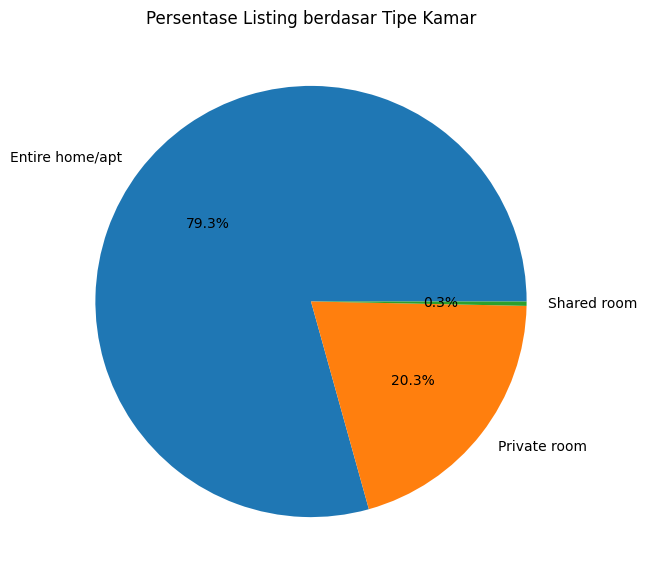

In [ ]:
segment=listings["room_type"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(segment.values,labels=segment.index,autopct="%1.1f%%")

plt.title("Persentase Listing berdasar Tipe Kamar")

plt.show()

## Kategori Kepemilikan Properti

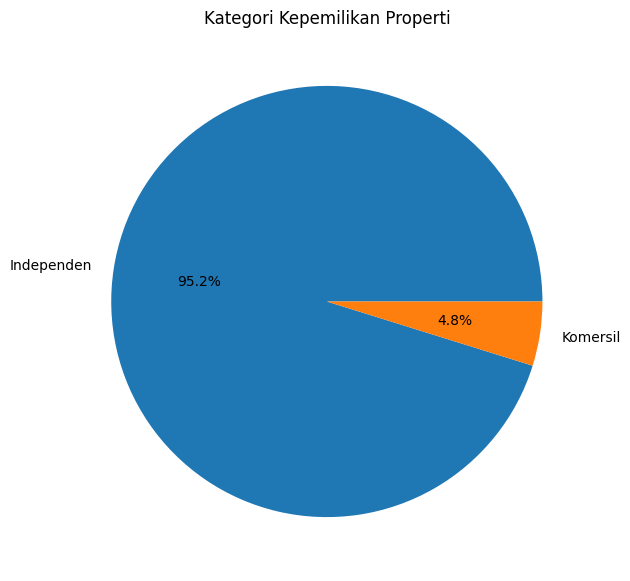

In [ ]:
segment = insight7["kategori"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(segment.values,labels=segment.index,autopct="%1.1f%%")

plt.title("Kategori Kepemilikan Properti")

plt.show()

## Tingkat Ketersediaan Listings per Bulan

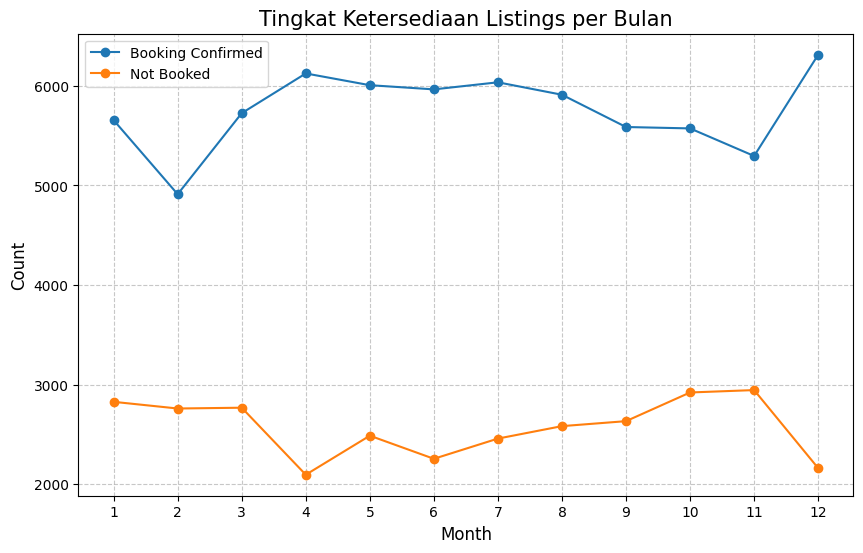

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(insight5['bulan'], insight5['bookingconfirmed'], marker='o', label='Booking Confirmed')
plt.plot(insight5['bulan'], insight5['notbooked'], marker='o', label='Not Booked')

plt.title('Tingkat Ketersediaan Listings per Bulan', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(insight5['bulan'])
plt.grid(linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Persentase Room Terbooking

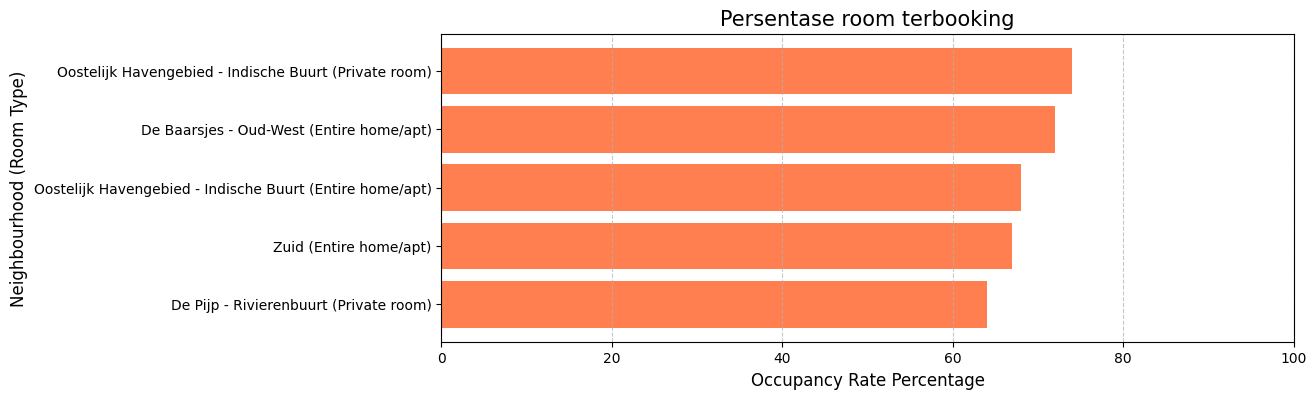

In [34]:
insight82_plot = insight82.copy()
insight82_plot['combined_label'] = insight82_plot['neighbourhood'] + ' (' + insight82_plot['room_type'] + ')'

insight82_sorted = insight82_plot.sort_values(by='occupancy_rate_percentage', ascending=False).head(5)

plt.figure(figsize=(11, 4))
plt.barh(insight82_sorted['combined_label'], insight82_sorted['occupancy_rate_percentage'], color='coral')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.title('Persentase room terbooking', fontsize=15)
plt.xlabel('Occupancy Rate Percentage', fontsize=12)
plt.ylabel('Neighbourhood (Room Type)', fontsize=12)
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.show()

# Visualisasi Seaborn

## Range Jumlah Hari Menginap

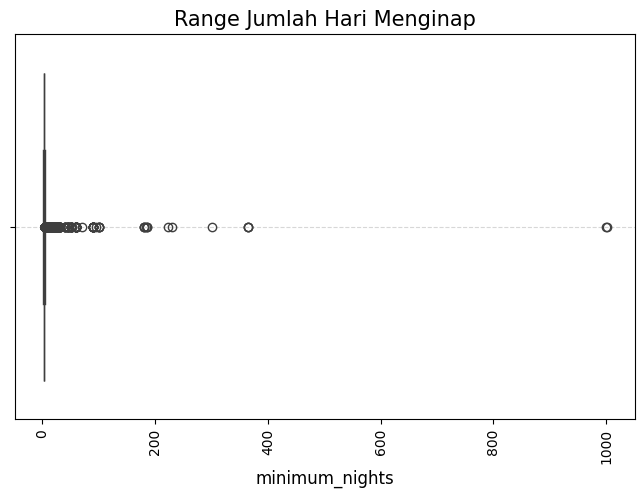

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=listings,x="minimum_nights", legend=True)
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.title("Range Jumlah Hari Menginap",fontsize=15)
plt.xlabel("minimum_nights",fontsize=12)
plt.xticks(rotation=90)
plt.show()


## Host dengan properti terbanyak

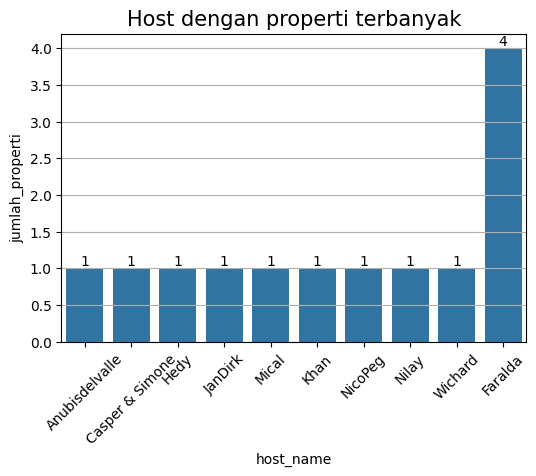

In [ ]:
insight4=(
insight4.groupby("host_name")["jumlah_properti"].sum()
.reset_index().sort_values("jumlah_properti", ascending=True))
plt.figure(figsize=(6,4))
ax=sns.barplot(data=insight4,x="host_name",y="jumlah_properti")
for i in ax.containers:
  ax.bar_label(i)
plt.grid(axis="y", linestyle="-")
plt.title("Host dengan properti terbanyak", fontsize=15)
plt.xticks(rotation=45)
plt.show ()

## Korelasi Listing, Harga dan Review

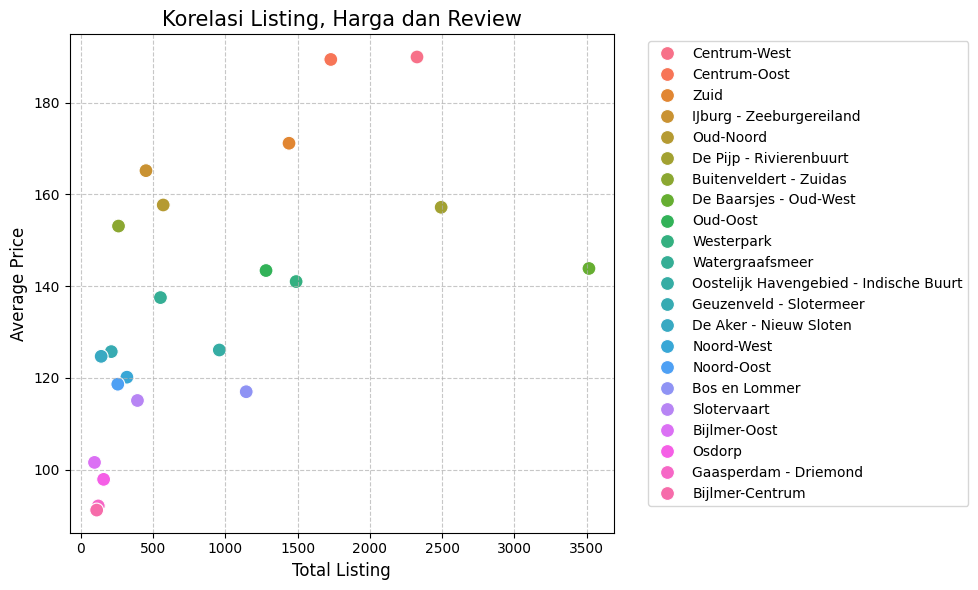

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=insight1, x="total_listing", y="avg_harga", hue="area", s=100)
plt.grid(linestyle="--", alpha=0.7)
plt.title("Korelasi Listing, Harga dan Review", fontsize=15)
plt.xlabel("Total Listing", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Range Harga Sewa

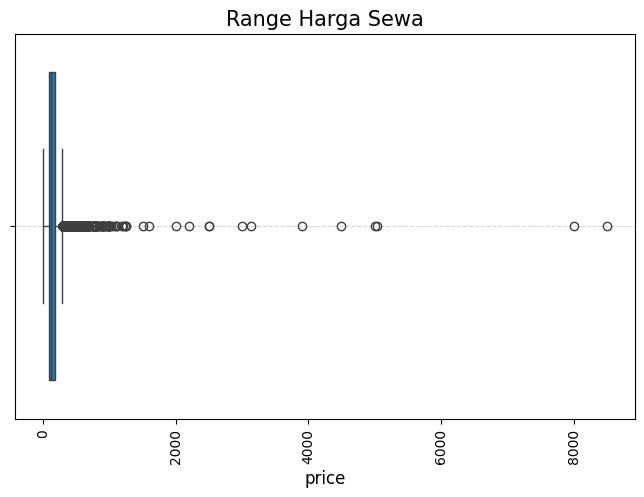

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=listings,x="price", legend=True)
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.title("Range Harga Sewa",fontsize=15)
plt.xlabel("price",fontsize=12)
plt.xticks(rotation=90)
plt.show()
